In [1]:
import math
import torch
import torch.nn as nn
from torch.nn import functional as F
from einops import rearrange

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


In [ ]:
def norm(x: torch.Tensor) -> torch.Tensor:
    return F.rms_norm(x, (x.size(-1),))

# Completed section

In [ ]:
class Patchify2D(nn.Module):
    def __init__(self, d_model: int, patch_size: int, color_channels: int):
        """
        input: (B, C, H, W)
        output: (B, N, D)
        """
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=color_channels, out_channels=d_model, kernel_size=patch_size, stride=patch_size
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # LINEAR CxHxW -> (H/p * W/p)xCPP -> (NxCPP) @ (CPP x d) -> NxD
        # CONV   CxHxW -> DxH/pxW/p       -> DxN -> NxD
        return rearrange(self.conv(x), "... d h w -> ...  (h w) d")
        

class Depatchify2D(nn.Module):
    def __init__(self, d_model: int, patch_size: int, color_channels: int, height: int, width: int):
        """
        input: (B, N, D)
        output: (B, C, H, W)
        """
        super().__init__()
        self.height = height
        self.width = width
        self.patch_size = patch_size
        
        self.deconv = nn.ConvTranspose2d(in_channels=d_model, out_channels=color_channels, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h1 = self.height // self.patch_size
        w1 = self.width // self.patch_size
        # x # B, N, D -> B, H/p, W/p, D -> B, D, H/p, W/p
        # N = h // p * w // p
        x = rearrange(x, "... (h1 w1) d ->... d h1 w1", h1 = h1, w1 = w1)
        return self.deconv(x)
    
class FourierTimeEmbedding(nn.Module):
    def __init__(self, t_channels: int, w_min: float = 1.0, w_max: float = 10000.0):
        super().__init__()
        self.t_channels = t_channels
        half_dim = t_channels // 2
        
        w = w_min * ((w_max / w_min) ** ((torch.linspace(start=1, end=half_dim, steps=half_dim) - 1) / (half_dim - 1)))
        self.register_buffer("w", w) # non trainable

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        args = 2 * math.pi * t * self.w.unsqueeze(0)
        emb = math.sqrt(2.0 / self.t_channels) * torch.cat([torch.cos(args), torch.sin(args)], dim=1) # Batch x t_channels
        
        if self.t_channels % 2 == 1:  # zero pad
            emb = nn.functional.pad(emb, (0, 1), mode='constant')
        return emb

In prog

In [ ]:
class RoPE(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return NotImplementedError

In [ ]:
class MultiHeadAttention(nn.Module): # TODO: RoPE
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        
        self.n_heads = n_heads
        self.qkv_weights = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        qkv =  self.qkv_weights(x) # B, T, 3 * d_model
        q, k, v = rearrange(qkv, "b t (k nh hs) -> k b nh t hs", k=3, nh=self.n_heads).unbind(0)
        
        out = F.scaled_dot_product_attention(q, k, v)
        out = rearrange(out, 'b nh t hs -> b t (nh hs)')
        return self.proj(out)

In [ ]:
class mmDiTBlock(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()

NameError: name 'nn' is not defined

In [ ]:
class DiT(nn.Module):
    def __init__(self, d_model: int, patch_size: int, color_channels: int, height: int, width: int, t_channels: int):
        super().__init__()
        
        self.patchify = Patchify2D(d_model, patch_size, color_channels)
        self.depatchify = Depatchify2D(d_model, patch_size, color_channels, height, width)
        
        self.time_embed = FourierTimeEmbedding(t_channels)
        
    def forward(self, input: torch.Tensor, time_steps: torch.Tensor) -> torch.Tensor: # timesteps: torch.Tensor, condition: torch.Tensor)
        input = self.patchify(input)
        time_steps = self.time_embed(time_steps)
        
        return self.depatchify(input)

model = DiT(d_model=256, patch_size=2, color_channels=3, height=256, width=256).to(device=device)

In [10]:
input = torch.load("RGBImageTensors.pt", weights_only=True).to(device)

In [13]:
output = model(input)

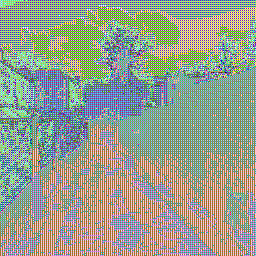

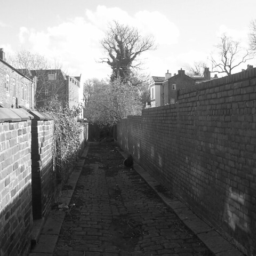

In [19]:
from torchvision.transforms import ToTensor, ToPILImage, transforms
from IPython.display import display
to_tensor = ToTensor()
to_image = ToPILImage()

display(to_image(output[32]))
display(to_image(input[32]))

In [ ]:
def modulate(x, shift, scale): # for AdaLN. modulate(nn.Linear(nn.LayerNorm()))
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)